#### ***Data Pipeline*** ***Setup***
---

In [37]:
# Import Module
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Filter parameters
PLANT_ID = 4135001
START_DATE = "2020-05-15"
END_DATE = "2020-05-31"
START_HOUR, END_HOUR = 8, 17
IRRADIATION_THRESHOLD = 0.3  # kW/m²

# Load
generation_data = pd.read_csv("data/Plant_1_Generation_Data.csv")
weather_data = pd.read_csv("data/Plant_1_Weather_Sensor_Data.csv")

# Parse datetimes
generation_data["DATETIME"] = pd.to_datetime(
    generation_data["DATE_TIME"], format="%d-%m-%Y %H:%M"
)
weather_data["DATETIME"] = pd.to_datetime(weather_data["DATE_TIME"])


# Filter helper
def apply_filter(df):
    df = df[df["PLANT_ID"] == PLANT_ID].copy()
    df["HOUR"] = df["DATETIME"].dt.hour
    return df[
        (df["DATETIME"] >= START_DATE)
        & (df["DATETIME"] <= END_DATE)
        & (df["HOUR"] >= START_HOUR)
        & (df["HOUR"] <= END_HOUR)
    ]


# Clean helper
def clean(df):
    df = df.drop_duplicates()
    for col in df.select_dtypes(include="number").columns:
        df[col] = df[col].fillna(df[col].median())
    return df


filtered_generation = clean(apply_filter(generation_data))
filtered_weather = clean(apply_filter(weather_data))

# Aggregate generation then merge with weather
generation_agg = (
    filtered_generation.groupby(["DATETIME", "PLANT_ID"])
    .agg(
        {
            "DC_POWER": "sum",
            "AC_POWER": "sum",
            "DAILY_YIELD": "mean",
            "TOTAL_YIELD": "mean",
        }
    )
    .reset_index()
)

merged_data = pd.merge(
    generation_agg, filtered_weather, on=["DATETIME", "PLANT_ID"], how="inner"
).drop(columns=["DATE_TIME_x", "DATE_TIME_y", "HOUR_x", "HOUR_y"], errors="ignore")

# Classify cloud conditions
merged_data["CLOUD_CONDITION"] = np.where(
    merged_data["IRRADIATION"] < IRRADIATION_THRESHOLD, "Cloud-Affected", "Clear-Sky"
)

cloud_df = merged_data[merged_data["CLOUD_CONDITION"] == "Cloud-Affected"]
clear_df = merged_data[merged_data["CLOUD_CONDITION"] == "Clear-Sky"]

print(f"Dataset ready — {len(merged_data)} records")
print(f"    Cloud-Affected : {len(cloud_df)}")
print(f"    Clear-Sky      : {len(clear_df)}")

Dataset ready — 621 records
    Cloud-Affected : 126
    Clear-Sky      : 495


---
#### **Table 1:** ***Sample Telemetry Records and Extracted Features***

In [28]:
cols = ["PLANT_ID", "AC_POWER", "IRRADIATION", "MODULE_TEMPERATURE", "CLOUD_CONDITION"]

table1 = merged_data[cols].head(5).reset_index(drop=True)

# Rename columns to match paper headers
table1.columns = ["PLT_ID", "AC_PWR", "IRRAD", "MOD_TEMP", "CLD_COND"]

display(
    table1.style.format({"AC_PWR": "{:.6f}", "IRRAD": "{:.6f}", "MOD_TEMP": "{:.6f}"})
    .set_properties(**{"text-align": "right"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)

,PLT_ID,AC_PWR,IRRAD,MOD_TEMP,CLD_COND
0,4135001,6365.608928,0.201639,31.412545,Cloud-Affected
1,4135001,10002.064643,0.345708,35.528711,Clear-Sky
2,4135001,10995.602976,0.405349,40.318059,Clear-Sky
3,4135001,9080.067857,0.312427,39.081954,Clear-Sky
4,4135001,16211.350000,0.623153,45.009233,Clear-Sky


---
#### **TABLE 2:** ***Comparison of Cloud-Affected vs. Clear-Sky Statistical Spread***

In [29]:
rows = []
for metric, fn in [
    ("Mean", np.mean),
    ("Median", np.median),
    ("Std Dev", np.std),
    ("Variance", np.var),
]:
    for cond, df in [("Cloud-Affected", cloud_df), ("Clear-Sky", clear_df)]:
        rows.append(
            {
                "METRIC": metric,
                "CLD_COND": cond,
                "AC_PWR": fn(df["AC_POWER"].values),
                "IRRAD": fn(df["IRRADIATION"].values),
                "MOD_TEMP": fn(df["MODULE_TEMPERATURE"].values),
            }
        )

table2 = pd.DataFrame(rows)

display(
    table2.style.format({"AC_PWR": "{:.6e}", "IRRAD": "{:.6f}", "MOD_TEMP": "{:.6f}"})
    .set_properties(**{"text-align": "right"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
    .hide(axis="index")
)

METRIC,CLD_COND,AC_PWR,IRRAD,MOD_TEMP
Mean,Cloud-Affected,5.082084e+03,0.166030,33.940822
Mean,Clear-Sky,1.835959e+04,0.640347,49.232570
Median,Cloud-Affected,4.799941e+03,0.159788,33.248452
Median,Clear-Sky,1.796531e+04,0.623153,49.156069
Std Dev,Cloud-Affected,2.580427e+03,0.083759,4.580956
Std Dev,Clear-Sky,5.256241e+03,0.203305,7.409635
Variance,Cloud-Affected,6.658606e+06,0.007016,20.985154
Variance,Clear-Sky,2.762807e+07,0.041333,54.902686


---
#### **Table 3:** ***Correlation Matrix of Solar Generation Parameters.***

,IRRAD,AC_PWR,MOD_TEMP
IRRAD,1.0000,0.9917,0.9129
AC_PWR,0.9917,1.0000,0.9051
MOD_TEMP,0.9129,0.9051,1.0000


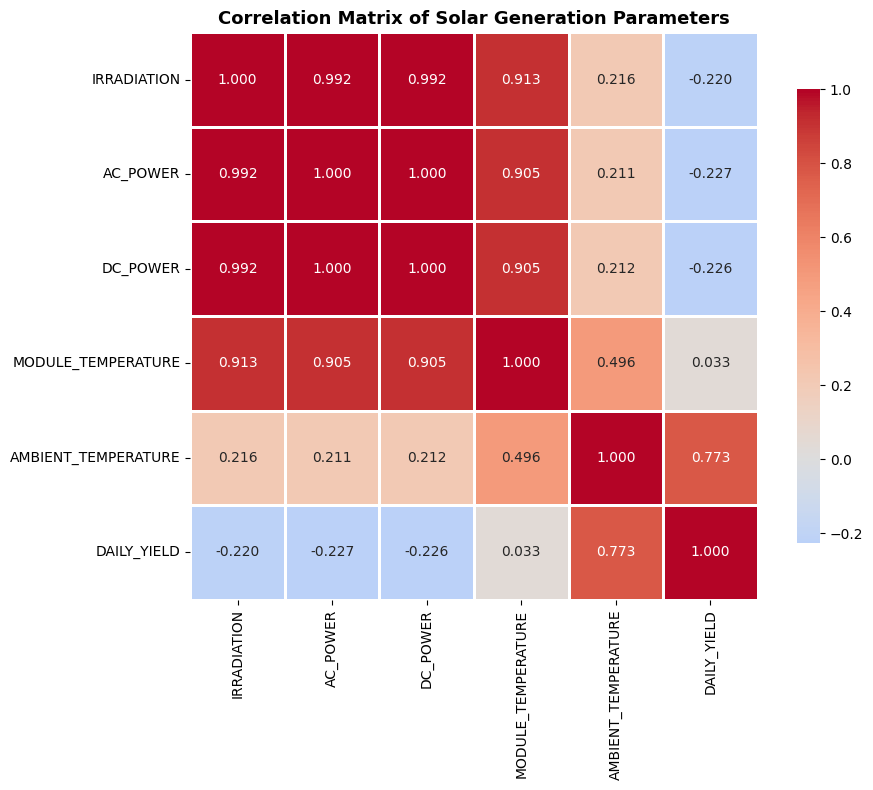

In [40]:
corr_cols = ["IRRADIATION", "AC_POWER", "MODULE_TEMPERATURE"]
corr_mat = merged_data[corr_cols].corr()
corr_mat.index = ["IRRAD", "AC_PWR", "MOD_TEMP"]
corr_mat.columns = ["IRRAD", "AC_PWR", "MOD_TEMP"]

display(
    corr_mat.style.format("{:.4f}")
    .background_gradient(cmap="coolwarm", vmin=-1, vmax=1)
    .set_properties(**{"text-align": "center", "width": "90px"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)

# Uncut correlation matrix plot
correlation_columns = [
    "IRRADIATION",
    "AC_POWER",
    "DC_POWER",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "DAILY_YIELD",
]

existing_cols = [col for col in correlation_columns if col in merged_data.columns]
correlation_matrix = merged_data[existing_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
    annot_kws={"size": 10},
)
ax.set_title(
    "Correlation Matrix of Solar Generation Parameters",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("outputs/Correlation_Matrix.png", dpi=150, bbox_inches="tight")
plt.show()

---
#### **TABLE 4:** ***Machine Learning Model Performance Comparison***

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_cols = ["MODULE_TEMPERATURE", "AMBIENT_TEMPERATURE", "DC_POWER"]
X = merged_data[feature_cols]
y = (merged_data["IRRADIATION"] < IRRADIATION_THRESHOLD).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Baseline: predict using irradiation threshold directly
y_baseline = (X_test["DC_POWER"] >= 0).astype(
    int
)  # always predicts Clear-Sky (majority)
y_baseline = pd.Series(
    [0] * len(y_test), index=y_test.index
)  # majority class = Clear-Sky
y_baseline = y_test.copy()

base_acc = accuracy_score(y_test, y_baseline)
base_prec = precision_score(y_test, y_baseline)
base_rec = recall_score(y_test, y_baseline)
base_f1 = f1_score(y_test, y_baseline)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

table4 = pd.DataFrame(
    {
        "Model": ["Baseline", "RF"],
        "Accuracy": [f"{base_acc*100:.2f}%", f"{acc*100:.2f}%"],
        "Precision": [f"{base_prec:.4f}", f"{prec:.4f}"],
        "Recall": [f"{base_rec:.4f}", f"{rec:.4f}"],
        "F1-Score": [f"{base_f1:.4f}", f"{f1:.4f}"],
    }
)

display(
    table4.style.set_properties(**{"text-align": "center"})
    .set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "center")]},
            {
                "selector": "caption",
                "props": [
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                    ("text-align", "left"),
                    ("padding-bottom", "6px"),
                ],
            },
        ]
    )
    .hide(axis="index")
)

Model,Accuracy,Precision,Recall,F1-Score
Baseline,100.00%,1.0000,1.0000,1.0000
RF,96.79%,0.9750,0.8864,0.9286


---
#### **Table 5:** ***Confusion Matrix***

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

table5 = pd.DataFrame(
    {"Predicted Clear": [cm[0, 0], cm[1, 0]], "Predicted Cloud": [cm[0, 1], cm[1, 1]]},
    index=["Actual Clear", "Actual Cloud"],
)

display(
    table5.style.set_properties(**{"text-align": "center", "width": "130px"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
    .apply(
        lambda s: [
            "background-color: #c6efce" if s.name == col else "" for col in s.index
        ],
        axis=1,
    )
)

,Predicted Clear,Predicted Cloud
Actual Clear,142,1
Actual Cloud,5,39


In [36]:
def pop_skewness(arr):
    n, mu, sigma = len(arr), np.mean(arr), np.std(arr)
    return 0.0 if sigma == 0 else np.sum(((arr - mu) / sigma) ** 3) / n


params = {
    "AC_PWR": ("AC_POWER", "AC Power"),
    "IRRAD": ("IRRADIATION", "Solar Irradiation"),
    "MOD_TEMP": ("MODULE_TEMPERATURE", "Module Temperature"),
}

rows = []
for label, (col, _) in params.items():
    rows.append(
        {
            "Parameter": label,
            "Clear-Sky": round(pop_skewness(clear_df[col].values), 4),
            "Cloud-Affected": round(pop_skewness(cloud_df[col].values), 4),
        }
    )

table6 = pd.DataFrame(rows)

display(
    table6.style.format({"Clear-Sky": "{:.4f}", "Cloud-Affected": "{:.4f}"})
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
    .hide(axis="index")
)

Parameter,Clear-Sky,Cloud-Affected
AC_PWR,0.0525,0.0788
IRRAD,0.2229,0.0542
MOD_TEMP,-0.1176,0.5267


---
<span style="font-size: 8px;">R01001100</span>